# Unit Root Processes in Time Series Analysis

## 1. Introduction

A **unit root** is a characteristic of a time series that makes it non-stationary. It arises when the autoregressive polynomial of an ARMA model has a root equal to 1.

The unit root concept is central to:
- Testing for stationarity
- Understanding stochastic trends
- ARIMA modeling (the "I" stands for Integrated)
- Avoiding spurious regression

## 2. Mathematical Definition

Consider the AR(1) process:

$$x_t = \phi x_{t-1} + \epsilon_t, \quad \epsilon_t \sim WN(0, \sigma^2)$$

The characteristic equation is:

$$1 - \phi z = 0 \implies z = \frac{1}{\phi}$$

A **unit root** occurs when $|z| = 1$, which implies $|\phi| = 1$.

### Cases:

| Case | Condition | Behavior |
|------|-----------|----------|
| **Stationary** | $|\phi| < 1$ | Mean-reverting, constant variance |
| **Unit Root** | $|\phi| = 1$ | Non-stationary, variance grows with $t$ |
| **Explosive** | $|\phi| > 1$ | Diverges exponentially |

### Random Walk (the canonical unit root process)

When $\phi = 1$:

$$x_t = x_{t-1} + \epsilon_t$$

By recursive substitution:

$$x_t = x_0 + \sum_{i=1}^{t} \epsilon_i$$

**Key properties:**
- $E[x_t] = x_0$ (constant mean, but only if $x_0$ is fixed)
- $\text{Var}(x_t) = t\sigma^2$ (variance grows linearly with time)
- Shocks are **permanent** (no mean reversion)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

# Suppress KPSS-related interpolation warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)

np.random.seed(42)
N = 250
t = np.arange(N)

# 1. Stationary AR(1): x_t = 0.7*x_{t-1} + eps
eps1 = np.random.normal(0, 1, N)
ar1_stationary = np.zeros(N)
for i in range(1, N):
    ar1_stationary[i] = 0.7 * ar1_stationary[i-1] + eps1[i]

# 2. Pure Random Walk I(1): x_t = x_{t-1} + eps
eps2 = np.random.normal(0, 1, N)
rw = np.cumsum(eps2)

# 3. Random Walk with Drift I(1): x_t = 0.2 + x_{t-1} + eps
eps3 = np.random.normal(0, 1, N)
rw_drift = np.cumsum(0.2 + eps3)

# 4. Trend Stationary (NO unit root): y_t = 0.05*t + u_t, u_t = 0.7*u_{t-1} + eps
eps4 = np.random.normal(0, 1, N)
u = np.zeros(N)
for i in range(1, N):
    u[i] = 0.7 * u[i-1] + eps4[i]
trend_stationary = 0.05 * t + u

# 5. Explosive AR(1): x_t = 1.03*x_{t-1} + eps
eps5 = np.random.normal(0, 1, N)
explosive = np.zeros(N)
for i in range(1, N):
    explosive[i] = 1.03 * explosive[i-1] + eps5[i]

series_dict = {
    "AR(1) Stationary (phi=0.7)": ar1_stationary,
    "Random Walk I(1) (phi=1.0)": rw,
    "RW with Drift I(1)": rw_drift,
    "Trend Stationary (no unit root)": trend_stationary,
    "Explosive AR(1) (phi=1.03)": explosive
}

print("Processes generated:")
for name, data in series_dict.items():
    print("  {}: mean={:.2f}, std={:.2f}".format(name, data.mean(), data.std()))

Processes generated:
  AR(1) Stationary (phi=0.7): mean=-0.02, std=1.28
  Random Walk I(1) (phi=1.0): mean=4.49, std=4.69
  RW with Drift I(1): mean=16.11, std=13.21
  Trend Stationary (no unit root): mean=6.67, std=3.67
  Explosive AR(1) (phi=1.03): mean=1857.17, std=3056.61


## 3. Visual Comparison

Notice the qualitative differences:
- **Stationary AR(1)**: Fluctuates around a fixed mean
- **Random Walk**: Wanders without returning to a mean
- **RW with Drift**: Wanders with a consistent upward slope
- **Trend Stationary**: Follows a trend but deviations are temporary
- **Explosive**: Grows rapidly, clearly unstable

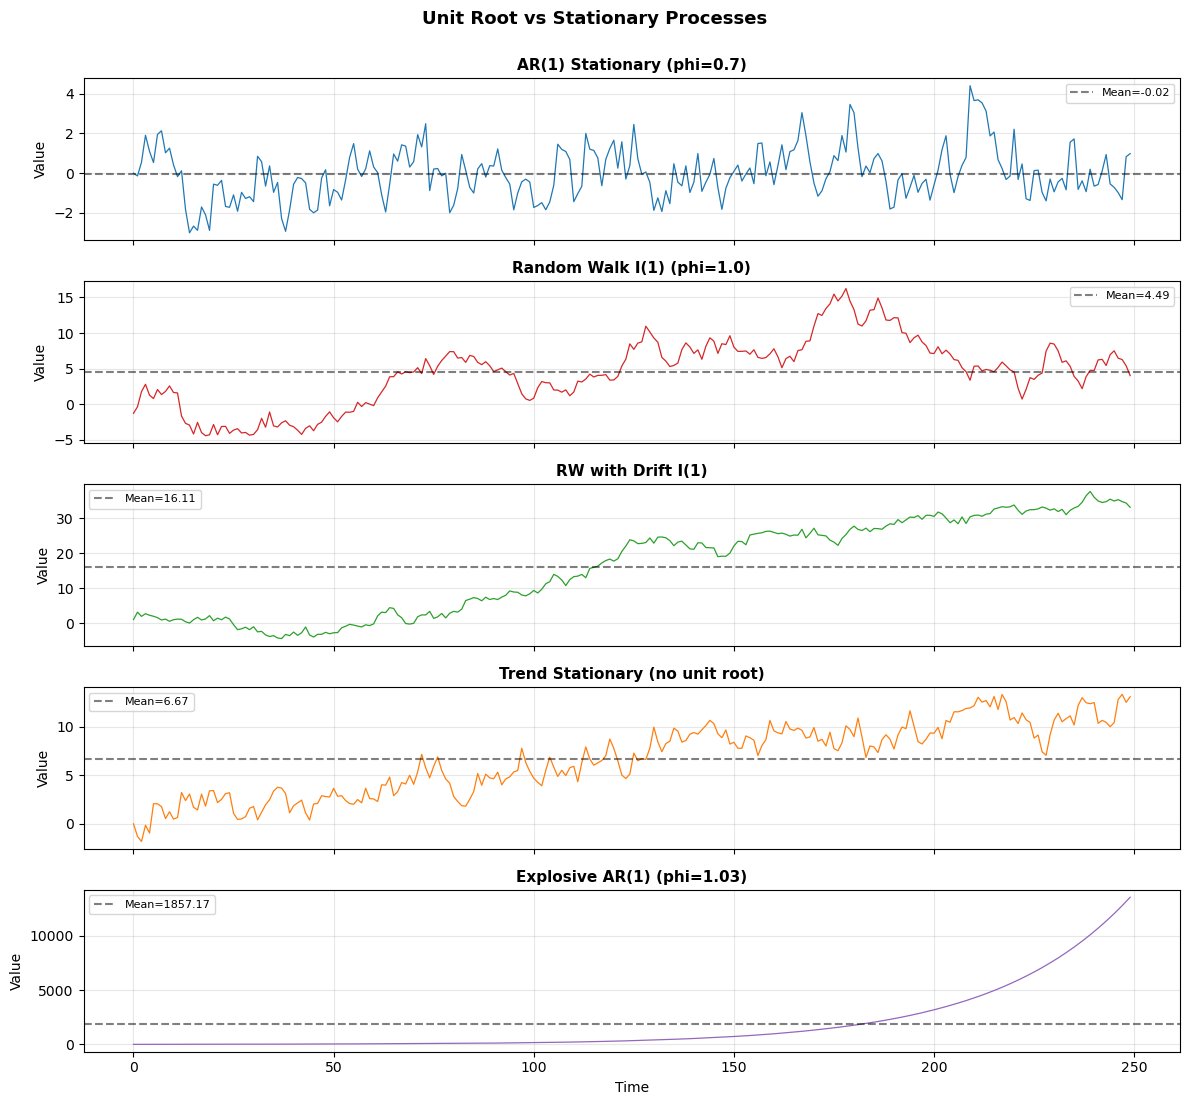

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True)

colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple']

for ax, ((name, data), color) in zip(axes, zip(series_dict.items(), colors)):
    ax.plot(t, data, color=color, linewidth=0.9)
    ax.axhline(y=data.mean(), color='black', linestyle='--', alpha=0.5, 
               label="Mean={:.2f}".format(data.mean()))
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel("Value")
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
plt.suptitle("Unit Root vs Stationary Processes", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## 4. Variance Growth: The Signature of a Unit Root

For a stationary AR(1) process with $|\phi| < 1$:

$$\text{Var}(x_t) = \frac{\sigma^2}{1 - \phi^2} \quad \text{(constant over time)}$$

For a random walk with $\phi = 1$:

$$\text{Var}(x_t) = t\sigma^2 \quad \text{(grows linearly with time)}$$

This **time-dependent variance** is the defining feature of a unit root process. Let's visualize it.

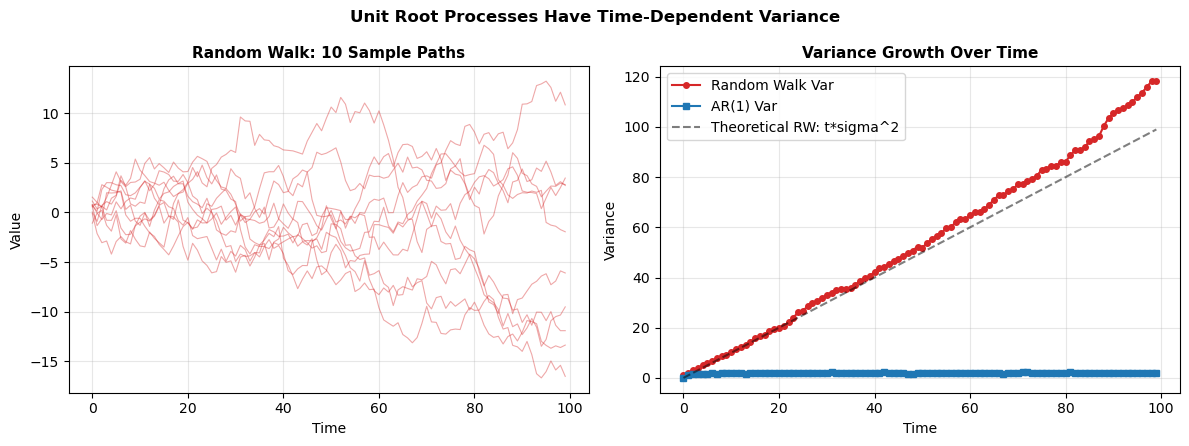

Random Walk variance at t=10:  10.44 (theoretical: 10)
Random Walk variance at t=50:  51.95 (theoretical: 50)
Random Walk variance at t=90:  105.46 (theoretical: 90)
AR(1) variance at t=90:        1.88 (should be constant)


In [10]:
# Simulate many paths to estimate variance at each time point
np.random.seed(123)
n_paths = 500
T = 100

# Random Walk paths
rw_paths = np.zeros((n_paths, T))
for p in range(n_paths):
    eps = np.random.normal(0, 1, T)
    rw_paths[p, :] = np.cumsum(eps)

# Stationary AR(1) paths
ar_paths = np.zeros((n_paths, T))
for p in range(n_paths):
    eps = np.random.normal(0, 1, T)
    for i in range(1, T):
        ar_paths[p, i] = 0.7 * ar_paths[p, i-1] + eps[i]

rw_var = np.var(rw_paths, axis=0)
ar_var = np.var(ar_paths, axis=0)
time_axis = np.arange(T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Sample paths
axes[0].plot(time_axis, rw_paths[:10].T, color='tab:red', alpha=0.4, linewidth=0.8)
axes[0].set_title("Random Walk: 10 Sample Paths", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

# Right: Variance over time
axes[1].plot(time_axis, rw_var, 'o-', color='tab:red', markersize=4, label='Random Walk Var', linewidth=1.5)
axes[1].plot(time_axis, ar_var, 's-', color='tab:blue', markersize=4, label='AR(1) Var', linewidth=1.5)
axes[1].plot(time_axis, time_axis, '--', color='black', alpha=0.5, label='Theoretical RW: t*sigma^2')

axes[1].set_title("Variance Growth Over Time", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Variance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Unit Root Processes Have Time-Dependent Variance", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Random Walk variance at t=10:  {:.2f} (theoretical: 10)".format(rw_var[10]))
print("Random Walk variance at t=50:  {:.2f} (theoretical: 50)".format(rw_var[50]))
print("Random Walk variance at t=90:  {:.2f} (theoretical: 90)".format(rw_var[90]))
print("AR(1) variance at t=90:        {:.2f} (should be constant)".format(ar_var[90]))


## 5. The Dickey-Fuller Test

The **Dickey-Fuller (DF)** test is the foundation for all unit root testing. It tests whether the AR(1) coefficient equals 1.

### Test Regression

$$\Delta x_t = \alpha + \beta t + \gamma x_{t-1} + \epsilon_t$$

where $\Delta x_t = x_t - x_{t-1}$.

### Hypotheses

- $H_0$: $\gamma = 0$  (unit root exists, series is non-stationary)
- $H_1$: $\gamma < 0$  (stationary, or trend-stationary)

### Three Specifications

| Model | Equation | Use When |
|-------|----------|----------|
| **No constant, no trend** | $\Delta x_t = \gamma x_{t-1} + \epsilon_t$ | Series known to have zero mean |
| **With constant** | $\Delta x_t = \alpha + \gamma x_{t-1} + \epsilon_t$ | Series may have non-zero mean |
| **With constant and trend** | $\Delta x_t = \alpha + \beta t + \gamma x_{t-1} + \epsilon_t$ | Series may have deterministic trend |

> The test statistic does **not** follow a standard t-distribution under $H_0$. It follows the **Dickey-Fuller distribution**, which is asymmetric and has more mass in the left tail.

In [11]:
def manual_dickey_fuller(x, regression='c'):
    """
    Manual implementation of the Dickey-Fuller test.
    regression: 'nc' (no constant), 'c' (constant), 'ct' (constant+trend)
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    
    # Create differenced series: dx_t = x_t - x_{t-1}
    dx = np.diff(x)
    x_lag = x[:-1]  # x_{t-1}
    
    # Build design matrix based on regression type
    if regression == 'nc':
        X = x_lag.reshape(-1, 1)
    elif regression == 'c':
        X = add_constant(x_lag, has_constant='add')
    elif regression == 'ct':
        trend = np.arange(1, n)
        X = np.column_stack((np.ones(n-1), trend, x_lag))
    else:
        raise ValueError("regression must be 'nc', 'c', or 'ct'")
    
    # OLS: dx = X * beta + eps
    model = OLS(dx, X).fit()
    
    # The coefficient on x_{t-1} is the last parameter
    gamma_hat = model.params[-1]
    gamma_se = model.bse[-1]
    t_stat = gamma_hat / gamma_se
    
    return {
        'gamma': gamma_hat,
        't_stat': t_stat,
        'p_value': model.pvalues[-1],  # Note: this p-value is NOT the DF p-value
        'r_squared': model.rsquared,
        'resid_std': np.std(model.resid, ddof=1)
    }


# Compare manual DF with statsmodels ADF on Random Walk
x_test = rw

manual_result = manual_dickey_fuller(x_test, regression='c')
sm_result = adfuller(x_test, autolag=None, maxlag=0, regression='c')

print("Manual Dickey-Fuller Results (Random Walk):")
print("  gamma (coefficient on x_{{t-1}}): {:.6f}".format(manual_result['gamma']))
print("  t-statistic:                      {:.4f}".format(manual_result['t_stat']))
print("  R-squared:                        {:.4f}".format(manual_result['r_squared']))

print("\nStatsmodels ADF Results (Random Walk):")
print("  ADF Statistic: {:.4f}".format(sm_result[0]))
print("  p-value:       {:.4f}".format(sm_result[1]))
print("  Critical Values:")
for key, val in sm_result[4].items():
    print("    {}: {:.4f}".format(key, val))

print("\nNote: The 't_stat' from manual OLS matches the ADF statistic.")
print("But the OLS p-value is WRONG for hypothesis testing — you must use DF critical values!")

Manual Dickey-Fuller Results (Random Walk):
  gamma (coefficient on x_{t-1}): -0.025428
  t-statistic:                      -1.9008
  R-squared:                        0.0144

Statsmodels ADF Results (Random Walk):
  ADF Statistic: -1.9008
  p-value:       0.3317
  Critical Values:
    1%: -3.4569
    5%: -2.8732
    10%: -2.5730

Note: The 't_stat' from manual OLS matches the ADF statistic.
But the OLS p-value is WRONG for hypothesis testing — you must use DF critical values!


## 6. Augmented Dickey-Fuller (ADF) Test

The simple DF test assumes the errors $\epsilon_t$ are white noise. In practice, they may be autocorrelated. The **ADF test** extends DF by adding lagged differences to soak up autocorrelation:

$$\Delta x_t = \alpha + \beta t + \gamma x_{t-1} + \sum_{j=1}^{p} \delta_j \Delta x_{t-j} + \epsilon_t$$

The **null hypothesis remains the same**: $\gamma = 0$ (unit root exists).

The lag order $p$ can be selected by:
- AIC/BIC information criteria
- Sequential testing (t-stat on last lag)
- Fixed lag length based on frequency (e.g., 12 for monthly data)

In [12]:
def adf_report(data, name, regression='c'):
    """
    Run ADF test and print comprehensive report.
    """
    result = adfuller(data, autolag='AIC', regression=regression)
    
    print("=" * 60)
    print("ADF Test: {}".format(name))
    print("  Regression type: {}".format(regression))
    print("=" * 60)
    print("  ADF Statistic:        {:.6f}".format(result[0]))
    print("  p-value:              {:.6f}".format(result[1]))
    print("  Number of Lags Used:  {}".format(result[2]))
    print("  Number of Observations: {}".format(result[3]))
    print("  Critical Values:")
    for key, val in result[4].items():
        print("    {:>6s}: {:.4f}".format(key, val))
    
    if result[1] < 0.05:
        print("  => REJECT H0: No unit root. Series is STATIONARY.")
    else:
        print("  => FAIL TO REJECT H0: Unit root present. Series is NON-STATIONARY.")
    print()


# Test all series with constant-only regression
for name, data in series_dict.items():
    adf_report(data, name, regression='c')

print("\n--- Trend-Stationary Series with 'ct' regression ---")
adf_report(trend_stationary, "Trend Stationary", regression='ct')

ADF Test: AR(1) Stationary (phi=0.7)
  Regression type: c
  ADF Statistic:        -7.099892
  p-value:              0.000000
  Number of Lags Used:  0
  Number of Observations: 249
  Critical Values:
        1%: -3.4569
        5%: -2.8732
       10%: -2.5730
  => REJECT H0: No unit root. Series is STATIONARY.

ADF Test: Random Walk I(1) (phi=1.0)
  Regression type: c
  ADF Statistic:        -1.900827
  p-value:              0.331672
  Number of Lags Used:  0
  Number of Observations: 249
  Critical Values:
        1%: -3.4569
        5%: -2.8732
       10%: -2.5730
  => FAIL TO REJECT H0: Unit root present. Series is NON-STATIONARY.

ADF Test: RW with Drift I(1)
  Regression type: c
  ADF Statistic:        -0.426185
  p-value:              0.905634
  Number of Lags Used:  0
  Number of Observations: 249
  Critical Values:
        1%: -3.4569
        5%: -2.8732
       10%: -2.5730
  => FAIL TO REJECT H0: Unit root present. Series is NON-STATIONARY.

ADF Test: Trend Stationary (no unit

## 7. Spurious Regression

One of the most dangerous consequences of unit roots is **spurious regression**. When two independent I(1) series are regressed on each other, they often appear highly correlated due to shared stochastic trends.

**Classic example (Granger & Newbold, 1974):**
- $x_t$ and $y_t$ are independent random walks
- Regress $y_t$ on $x_t$
- Result: High $R^2$, significant t-statistic — but the relationship is completely fake!

This happens because both series contain the same "trend" component (accumulated shocks).

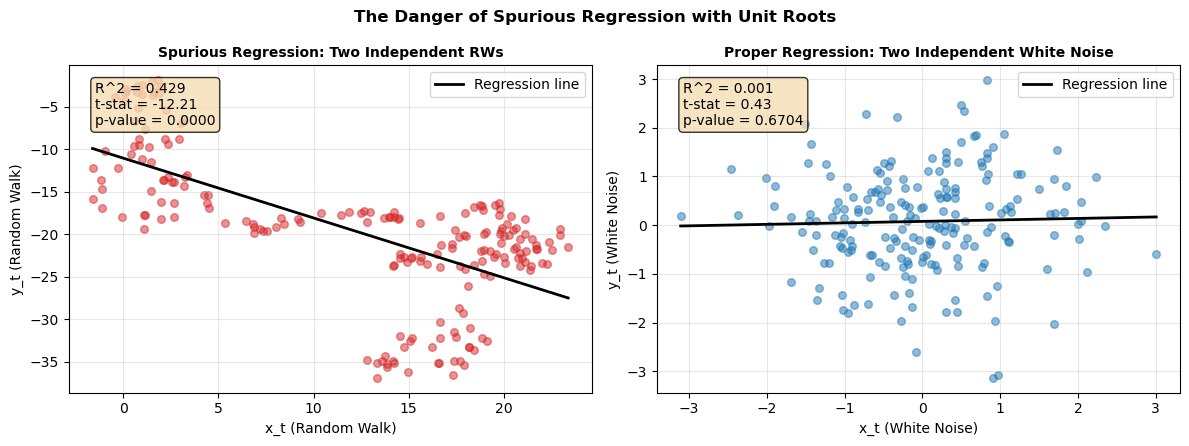

SPURIOUS (Random Walks):
  Slope coefficient: -0.7040
  R-squared:         0.4294
  t-statistic:       -12.2059
  p-value:           0.0000

PROPER (White Noise):
  Slope coefficient: 0.0304
  R-squared:         0.0009
  t-statistic:       0.4262
  p-value:           0.6704


In [13]:
np.random.seed(999)

# Two INDEPENDENT random walks
n = 200
eps_x = np.random.normal(0, 1, n)
eps_y = np.random.normal(0, 1, n)

x_spur = np.cumsum(eps_x)
y_spur = np.cumsum(eps_y)

# Spurious regression: y ~ x
X_spur = add_constant(x_spur, has_constant='add')
model_spur = OLS(y_spur, X_spur).fit()

# For comparison: regression on stationary series
x_stat = np.random.normal(0, 1, n)
y_stat = np.random.normal(0, 1, n)
X_stat = add_constant(x_stat, has_constant='add')
model_stat = OLS(y_stat, X_stat).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Spurious regression
axes[0].scatter(x_spur, y_spur, alpha=0.5, s=30, color='tab:red')
x_line = np.linspace(x_spur.min(), x_spur.max(), 100)
axes[0].plot(x_line, model_spur.params[0] + model_spur.params[1] * x_line, 
             'k-', linewidth=2, label='Regression line')
axes[0].set_title("Spurious Regression: Two Independent RWs", fontsize=10, fontweight='bold')
axes[0].set_xlabel("x_t (Random Walk)")
axes[0].set_ylabel("y_t (Random Walk)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add text box
textstr = "R^2 = {:.3f}\nt-stat = {:.2f}\np-value = {:.4f}".format(
    model_spur.rsquared, model_spur.tvalues[1], model_spur.pvalues[1])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

# Right: Stationary regression
axes[1].scatter(x_stat, y_stat, alpha=0.5, s=30, color='tab:blue')
x_line_s = np.linspace(x_stat.min(), x_stat.max(), 100)
axes[1].plot(x_line_s, model_stat.params[0] + model_stat.params[1] * x_line_s, 
             'k-', linewidth=2, label='Regression line')
axes[1].set_title("Proper Regression: Two Independent White Noise", fontsize=10, fontweight='bold')
axes[1].set_xlabel("x_t (White Noise)")
axes[1].set_ylabel("y_t (White Noise)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

textstr_s = "R^2 = {:.3f}\nt-stat = {:.2f}\np-value = {:.4f}".format(
    model_stat.rsquared, model_stat.tvalues[1], model_stat.pvalues[1])
axes[1].text(0.05, 0.95, textstr_s, transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

plt.suptitle("The Danger of Spurious Regression with Unit Roots", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("SPURIOUS (Random Walks):")
print("  Slope coefficient: {:.4f}".format(model_spur.params[1]))
print("  R-squared:         {:.4f}".format(model_spur.rsquared))
print("  t-statistic:       {:.4f}".format(model_spur.tvalues[1]))
print("  p-value:           {:.4f}".format(model_spur.pvalues[1]))

print("\nPROPER (White Noise):")
print("  Slope coefficient: {:.4f}".format(model_stat.params[1]))
print("  R-squared:         {:.4f}".format(model_stat.rsquared))
print("  t-statistic:       {:.4f}".format(model_stat.tvalues[1]))
print("  p-value:           {:.4f}".format(model_stat.pvalues[1]))


## 8. Removing the Unit Root: Differencing

If a series has a unit root, we can often make it stationary by **differencing**:

$$\nabla x_t = x_t - x_{t-1}$$

For a random walk:
$$\nabla x_t = (x_{t-1} + \epsilon_t) - x_{t-1} = \epsilon_t$$

The first difference of a random walk is **white noise** — perfectly stationary!

For a random walk with drift:
$$\nabla x_t = \mu + \epsilon_t$$

The first difference is stationary around a constant mean $\mu$.

This is the basis of the **ARIMA(p,d,q)** model, where $d$ is the number of differences needed.

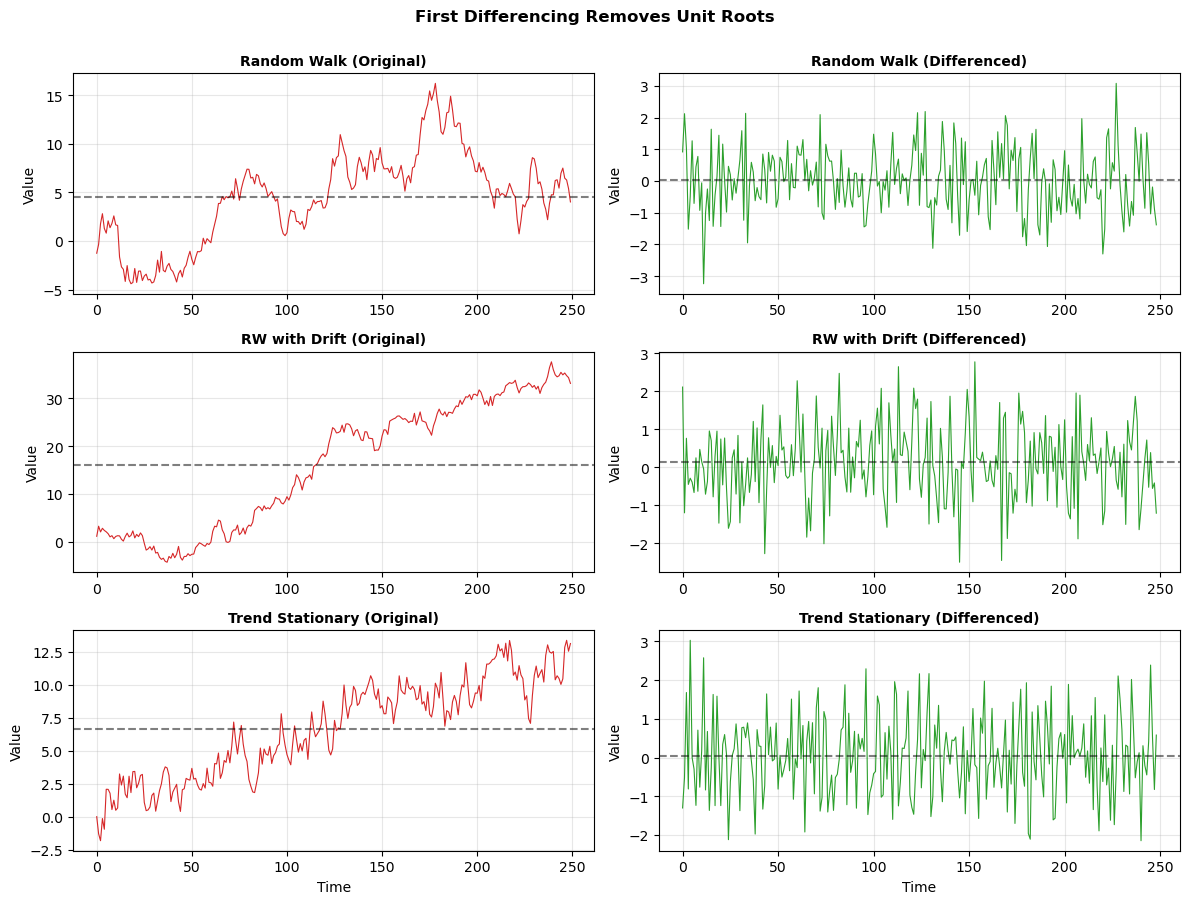

ADF on Differenced Series:
  Random Walk diff:     p-value = 0.000000
  RW with Drift diff:   p-value = 0.000000
  Trend Stationary diff: p-value = 0.000000


In [14]:
# Apply first differencing to non-stationary series
rw_diff = np.diff(rw)
rw_drift_diff = np.diff(rw_drift)
trend_diff = np.diff(trend_stationary)

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

transform_pairs = [
    ("Random Walk (Original)", rw, "Random Walk (Differenced)", rw_diff),
    ("RW with Drift (Original)", rw_drift, "RW with Drift (Differenced)", rw_drift_diff),
    ("Trend Stationary (Original)", trend_stationary, "Trend Stationary (Differenced)", trend_diff)
]

for i, (orig_name, orig_data, diff_name, diff_data) in enumerate(transform_pairs):
    # Original
    axes[i, 0].plot(orig_data, color='tab:red', linewidth=0.8)
    axes[i, 0].axhline(y=orig_data.mean(), color='black', linestyle='--', alpha=0.5)
    axes[i, 0].set_title(orig_name, fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel("Value")
    axes[i, 0].grid(True, alpha=0.3)
    
    # Differenced
    axes[i, 1].plot(diff_data, color='tab:green', linewidth=0.8)
    axes[i, 1].axhline(y=diff_data.mean(), color='black', linestyle='--', alpha=0.5)
    axes[i, 1].set_title(diff_name, fontsize=10, fontweight='bold')
    axes[i, 1].set_ylabel("Value")
    axes[i, 1].grid(True, alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Time")

plt.suptitle("First Differencing Removes Unit Roots", fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# Verify with ADF on differenced series
print("ADF on Differenced Series:")
print("  Random Walk diff:     p-value = {:.6f}".format(adfuller(rw_diff, autolag='AIC')[1]))
print("  RW with Drift diff:   p-value = {:.6f}".format(adfuller(rw_drift_diff, autolag='AIC')[1]))
print("  Trend Stationary diff: p-value = {:.6f}".format(adfuller(trend_diff, autolag='AIC')[1]))


## 9. Order of Integration: I(d)

The **order of integration** $d$ is the minimum number of differences required to make a series stationary.

| Notation | Meaning | Example |
|----------|---------|---------|
| **I(0)** | Already stationary | White noise, ARMA processes |
| **I(1)** | Needs 1 difference | Random walk, most economic series |
| **I(2)** | Needs 2 differences | Random walk of a random walk (rare) |

### Rules for combining integrated series:

- $I(0) + I(0) = I(0)$
- $I(1) + I(0) = I(1)$
- $I(1) + I(1) = I(1)$ or $I(0)$ if **cointegrated**
- $I(d) + I(d) = I(d)$

**Cointegration**: Two I(1) series may have a stationary linear combination. This is the foundation of error-correction models.


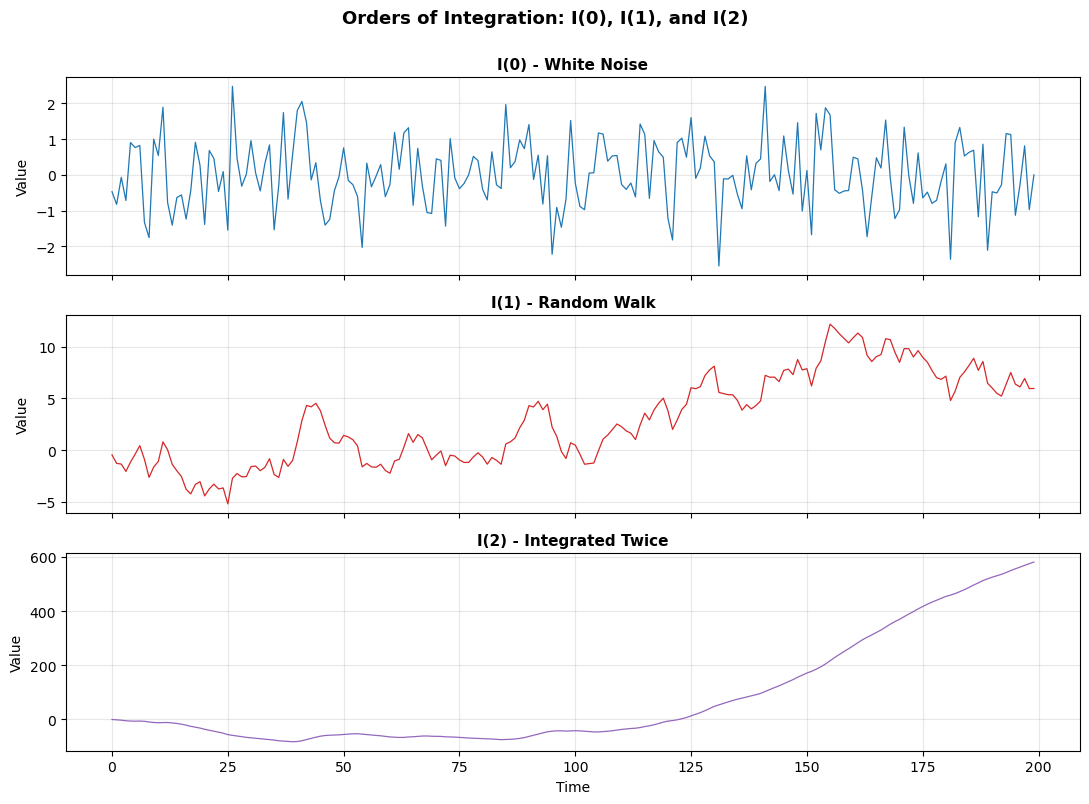

ADF Tests on Integration Orders:
  I(0) - White Noise       : ADF=-13.0044, p-value=0.000000
  I(1) - Random Walk       : ADF= -1.5907, p-value=0.488272
  I(2) - Integrated Twice  : ADF=  0.4077, p-value=0.981782

After First Differencing:
  I(0) - White Noise diff  : ADF= -6.9555, p-value=0.000000
  I(1) - Random Walk diff  : ADF=-13.0181, p-value=0.000000
  I(2) - Integrated Twice diff: ADF= -1.6429, p-value=0.460769

After Second Differencing (I(2) only):
  I(2) diff twice          : ADF=-12.9613, p-value=0.000000


In [15]:
np.random.seed(777)

# I(0): White noise
i0 = np.random.normal(0, 1, 200)

# I(1): Random walk (cumsum of I(0))
i1 = np.cumsum(i0)

# I(2): Random walk of random walk (cumsum of I(1))
i2 = np.cumsum(i1)

integration_series = {
    "I(0) - White Noise": i0,
    "I(1) - Random Walk": i1,
    "I(2) - Integrated Twice": i2
}

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

colors_i = ['tab:blue', 'tab:red', 'tab:purple']

for ax, ((name, data), color) in zip(axes, zip(integration_series.items(), colors_i)):
    ax.plot(data, color=color, linewidth=0.9)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
plt.suptitle("Orders of Integration: I(0), I(1), and I(2)", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# ADF tests on each
print("ADF Tests on Integration Orders:")
for name, data in integration_series.items():
    result = adfuller(data, autolag='AIC')
    print("  {:25s}: ADF={:8.4f}, p-value={:.6f}".format(name, result[0], result[1]))

# Differences
print("\nAfter First Differencing:")
for name, data in integration_series.items():
    if len(data) > 1:
        diff = np.diff(data)
        result = adfuller(diff, autolag='AIC')
        print("  {:25s}: ADF={:8.4f}, p-value={:.6f}".format(name + " diff", result[0], result[1]))

print("\nAfter Second Differencing (I(2) only):")
i2_diff2 = np.diff(np.diff(i2))
result = adfuller(i2_diff2, autolag='AIC')
print("  {:25s}: ADF={:8.4f}, p-value={:.6f}".format("I(2) diff twice", result[0], result[1]))

## 10. ACF of Unit Root Processes

The ACF of a unit root process decays **extremely slowly** — another diagnostic tool.

| Process | ACF Behavior |
|---------|-------------|
| Stationary AR(1) | Exponential decay to zero |
| Random Walk I(1) | Linear decay: $\rho(k) \approx \sqrt{(T-k)/T}$ (very slow) |
| White Noise I(0) | Near zero for all $k > 0$ |

For a random walk, the theoretical ACF at lag $k$ for a series of length $T$ is approximately:

$$\rho(k) \approx \sqrt{\frac{T - k}{T}}$$

This means even at large lags, the ACF remains high — a clear sign of non-stationarity.


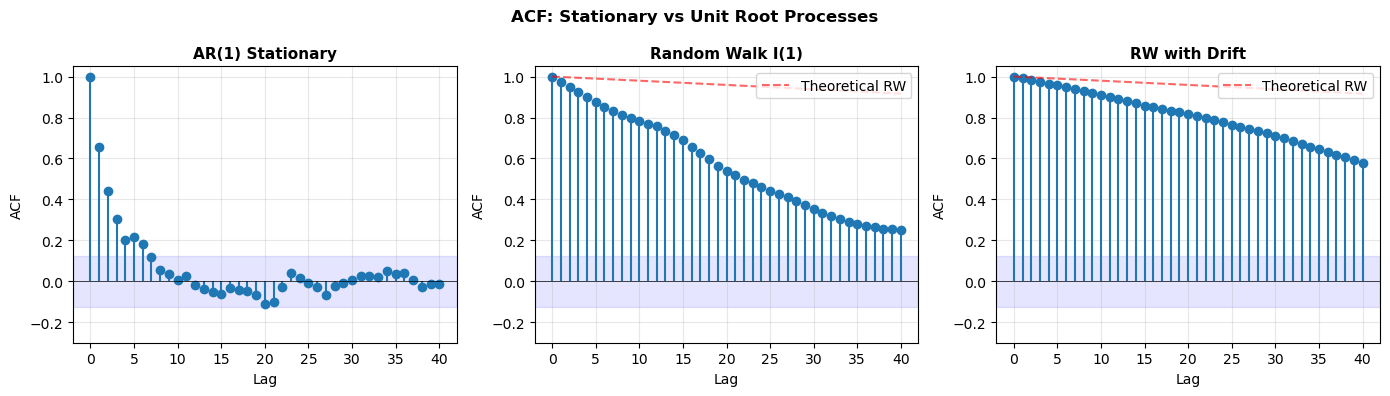

ACF at Lag 20:
  AR(1) Stationary    : -0.1129
  Random Walk I(1)    : 0.5400
  RW with Drift       : 0.8159


In [16]:
def manual_acf(data, max_lags=40):
    N = len(data)
    max_lags = min(max_lags, N - 1)
    x_centered = data - data.mean()
    autocov = np.zeros(max_lags + 1)
    for k in range(max_lags + 1):
        autocov[k] = np.sum(x_centered[k:] * x_centered[:N-k]) / N
    return autocov / autocov[0]


max_lags = 40
lags = np.arange(max_lags + 1)
conf = 1.96 / np.sqrt(N)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

acf_data = [
    ("AR(1) Stationary", ar1_stationary),
    ("Random Walk I(1)", rw),
    ("RW with Drift", rw_drift)
]

for ax, (name, data) in zip(axes, acf_data):
    acf_vals = manual_acf(data, max_lags)
    
    ax.stem(lags, acf_vals, basefmt=" ")
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhspan(-conf, conf, color='blue', alpha=0.1)
    
    # Theoretical RW ACF approximation
    if "Random" in name or "RW" in name:
        T = len(data)
        theoretical = np.array([np.sqrt((T - k) / T) for k in lags])
        ax.plot(lags, theoretical, 'r--', alpha=0.6, linewidth=1.5, label='Theoretical RW')
        ax.legend(loc='upper right')
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_ylim(-0.3, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle("ACF: Stationary vs Unit Root Processes", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print decay comparison
print("ACF at Lag 20:")
for name, data in acf_data:
    acf_vals = manual_acf(data, 20)
    print("  {:20s}: {:.4f}".format(name, acf_vals[20]))


## 11. Practical Decision Flowchart

When you encounter a new time series, follow this workflow:

1. 
VISUAL INSPECTION  |  +---> Trend or wandering behavior? ---> ADF Test  |  +---> Seasonal pattern? ---> Consider seasonal differencing  |  +---> Changing variance? ---> Log transform first
2. 
ADF TEST  |  +---> p < 0.05 (Reject H0) ---> Series is I(0), model with ARMA  |  +---> p >= 0.05 (Fail to reject) ---> Series has unit root
3. 
DIFFERENCE THE SERIES  |  +---> Re-run ADF on differenced data  |  +---> Still non-stationary? ---> Difference again (check for over-differencing)
4. 
MODEL THE STATIONARY SERIES  |  +---> Identify AR and MA orders via ACF/PACF  |  +---> Fit ARIMA(p,d,q) or SARIMA




### Warning: Over-Differencing

Differencing too many times can:
- Introduce artificial structure (MA terms)
- Increase variance
- Lose information

**Rule of thumb:** Only difference until the ADF test rejects the null. If you need $d > 2$, reconsider your model specification.


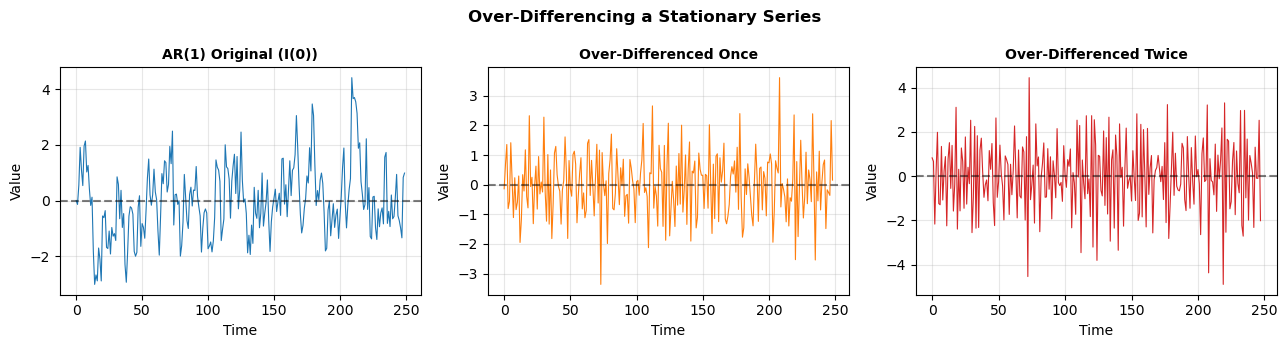

Variance after over-differencing:
  Original AR(1):         1.6430
  After 1 difference:     1.1238
  After 2 differences:    2.6685

ADF p-values:
  Original AR(1):         0.000000
  After 1 difference:     0.000000
  After 2 differences:    0.000000


In [17]:
# Demonstrate over-differencing on stationary AR(1)
ar_over = ar1_stationary.copy()

# Difference a stationary series (bad idea!)
ar_over_diff1 = np.diff(ar_over)
ar_over_diff2 = np.diff(ar_over_diff1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

datasets = [
    ("AR(1) Original (I(0))", ar_over, 'tab:blue'),
    ("Over-Differenced Once", ar_over_diff1, 'tab:orange'),
    ("Over-Differenced Twice", ar_over_diff2, 'tab:red')
]

for ax, (name, data, color) in zip(axes, datasets):
    ax.plot(data, color=color, linewidth=0.8)
    ax.axhline(y=data.mean(), color='black', linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel("Value")
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

plt.suptitle("Over-Differencing a Stationary Series", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare variances
print("Variance after over-differencing:")
print("  Original AR(1):         {:.4f}".format(np.var(ar_over, ddof=1)))
print("  After 1 difference:     {:.4f}".format(np.var(ar_over_diff1, ddof=1)))
print("  After 2 differences:    {:.4f}".format(np.var(ar_over_diff2, ddof=1)))

print("\nADF p-values:")
print("  Original AR(1):         {:.6f}".format(adfuller(ar_over, autolag='AIC')[1]))
print("  After 1 difference:     {:.6f}".format(adfuller(ar_over_diff1, autolag='AIC')[1]))
print("  After 2 differences:    {:.6f}".format(adfuller(ar_over_diff2, autolag='AIC')[1]))

## 12. Summary Table

| Process | Unit Root? | ADF Expected | Variance | ACF Decay | Fix |
|---------|-----------|--------------|----------|-----------|-----|
| White Noise | No | Reject H0 | Constant | Immediate | None |
| Stationary AR(1) | No | Reject H0 | Constant | Exponential | None |
| Random Walk | **Yes** | Fail to reject | Grows with $t$ | Very slow | First difference |
| RW with Drift | **Yes** | Fail to reject | Grows with $t$ | Very slow | First difference |
| Trend Stationary | No* | Depends on spec | Constant around trend | Slow | Detrend or use 'ct' ADF |
| Explosive | No (worse) | Reject H0 | Explodes | N/A | Transform or model differently |

*Trend stationary series appear non-stationary under ADF with 'c' but stationary under 'ct'.

In [18]:
# Final comprehensive summary
print("=" * 75)
print("UNIT ROOT ANALYSIS: COMPLETE SUMMARY")
print("=" * 75)

all_series = {
    "AR(1) phi=0.7": ar1_stationary,
    "Random Walk": rw,
    "RW with Drift": rw_drift,
    "Trend Stationary": trend_stationary,
    "Explosive phi=1.03": explosive
}

print("\n{:<25s} {:>10s} {:>12s} {:>15s} {:>12s}".format(
    "Series", "ADF Stat", "ADF p-val", "Variance", "ACF@lag20"))
print("-" * 75)

for name, data in all_series.items():
    adf_res = adfuller(data, autolag='AIC')
    var = np.var(data, ddof=1)
    acf20 = manual_acf(data, 20)[20]
    
    print("{:<25s} {:>10.4f} {:>12.6f} {:>15.2f} {:>12.4f}".format(
        name, adf_res[0], adf_res[1], var, acf20))

print("-" * 75)
print("\nKey Takeaways:")
print("1. Unit root => ADF fails to reject H0 (high p-value)")
print("2. Unit root => variance grows without bound")
print("3. Unit root => ACF decays extremely slowly")
print("4. First differencing usually removes the unit root")
print("5. Never regress I(1) on I(1) without testing for cointegration!")
print("=" * 75)


UNIT ROOT ANALYSIS: COMPLETE SUMMARY

Series                      ADF Stat    ADF p-val        Variance    ACF@lag20
---------------------------------------------------------------------------
AR(1) phi=0.7                -7.0999     0.000000            1.64      -0.1129
Random Walk                  -1.9008     0.331672           22.07       0.5400
RW with Drift                -0.4262     0.905634          175.21       0.8159
Trend Stationary             -1.6500     0.457053           13.49       0.6650
Explosive phi=1.03           17.3152     1.000000      9380374.12       0.5243
---------------------------------------------------------------------------

Key Takeaways:
1. Unit root => ADF fails to reject H0 (high p-value)
2. Unit root => variance grows without bound
3. Unit root => ACF decays extremely slowly
4. First differencing usually removes the unit root
5. Never regress I(1) on I(1) without testing for cointegration!


## 13. References & Further Reading

- Dickey, D. A. & Fuller, W. A. (1979). "Distribution of the Estimators for Autoregressive Time Series with a Unit Root"
- Granger, C. W. J. & Newbold, P. (1974). "Spurious Regressions in Econometrics"
- Hamilton, J. D. (1994). *Time Series Analysis* — Chapters 15-17
- Box, G. E. P. & Jenkins, G. M. (1976). *Time Series Analysis: Forecasting and Control*

### Key Python Functions Used:
- `statsmodels.tsa.stattools.adfuller()` — Augmented Dickey-Fuller test
- `statsmodels.regression.linear_model.OLS()` — Manual DF regression
- `numpy.diff()` — First differencing
- `numpy.cumsum()` — Building random walks from white noise